In [1]:
import pandas as pd
from scipy.stats import kendalltau, pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
from pathlib import Path
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm
import numpy as np
import matplotlib as mpl
from cellseg_benchmark._constants import method_colors
import matplotlib.lines as mlines

In [2]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

In [3]:
jin_dea_path = "/dss/dsshome1/00/ra87rib/cellseg-benchmark/misc/Jin_Nature_2025_full_de_results.csv"
out_path = Path("/dss/dsshome1/00/ra87rib/260607_daten_bilder_MA")
Pro_CP1_nuc_dea_path = "/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/aging/Proseg_3D_Cellpose_1_nuclei_model/dea/aging-by-celltype_MAST_2k_MAST_m18vsm3.xlsx"
cell_type_map = {
    "ECs": "Endo NN_1", 
    "Microglia": "Microglia NN_1", 
    "OPCs": "OPC NN_1", 
    "Pericytes": "Peri NN_1", 
    "SMCs": "SMC NN_1"
}

In [4]:
breaks = [1e-3, 0.001, 0.01, 0.05]

cmap = plt.get_cmap("Set3", len(breaks) - 1)
norm = mcolors.BoundaryNorm(breaks, cmap.N)


In [6]:
jin_dea = pd.read_csv(jin_dea_path)
jin_dea_sub = jin_dea[jin_dea['subclass'].isin(["Endo NN_1", "Microglia NN_1", "OPC NN_1", "Peri NN_1", "SMC NN_1"])]
dea = pd.read_excel(Pro_CP1_nuc_dea_path, sheet_name=None)

In [7]:
methods = [x for x in os.listdir("/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/aging") if not x.startswith("Negative") and x not in ["SIS_DAPI_total_mrna", "Watershed_Merlin"]]
methods.sort()
methods

['Baysor_2D_Cellpose_1_DAPI_PolyT_0.2',
 'Baysor_2D_Cellpose_1_DAPI_PolyT_0.8',
 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2',
 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8',
 'Baysor_2D_Cellpose_1_nuclei_model_1.0',
 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.2',
 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.8',
 'Baysor_2D_Cellpose_2_DAPI_Transcripts_0.2',
 'Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8',
 'Cellpose_1_DAPI_PolyT',
 'Cellpose_1_DAPI_Transcripts',
 'Cellpose_1_Merlin',
 'Cellpose_1_nuclei_model',
 'Cellpose_2_DAPI_PolyT',
 'Cellpose_2_DAPI_Transcripts',
 'Proseg_3D_Cellpose_1_DAPI_PolyT',
 'Proseg_3D_Cellpose_1_DAPI_Transcripts',
 'Proseg_3D_Cellpose_1_nuclei_model',
 'Proseg_3D_Cellpose_2_DAPI_PolyT',
 'Proseg_3D_Cellpose_2_DAPI_Transcripts',
 'Proseg_3D_vpt3D_DAPI_PolyT',
 'Proseg_3D_vpt3D_DAPI_PolyT_nuclei',
 'Proseg_3D_vpt3D_DAPI_nuclei',
 'vpt_2D_DAPI_PolyT',
 'vpt_2D_DAPI_PolyT_nuclei',
 'vpt_2D_DAPI_nuclei',
 'vpt_3D_DAPI_PolyT',
 'vpt_3D_DAPI_PolyT_nuclei',
 'vpt_3D_DAPI_nuclei']

In [10]:
dea['ECs']

,subset,gene,FC,PValue,FDR,wald,method,test_group,ref,test,log2FC,subset_group,model,test_group_n,ref_n,ensembl_id
0,ECs,Itm2a,0.829446,4.326031e-42,1.345396e-39,-10.349518,MAST,m18,m3,m18vsm3,-0.269781,ECs,~ age_months_mod + slide,3,3,ENSMUSG00000031239
1,ECs,Cldn5,0.776944,2.076024e-39,3.228217e-37,-10.506048,MAST,m18,m3,m18vsm3,-0.364118,ECs,~ age_months_mod + slide,3,3,ENSMUSG00000041378
2,ECs,Col4a1,0.861816,1.118331e-31,1.159337e-29,-9.641444,MAST,m18,m3,m18vsm3,-0.214548,ECs,~ age_months_mod + slide,3,3,ENSMUSG00000031502
3,ECs,Car4,0.870197,5.634632e-27,4.380926e-25,-7.758751,MAST,m18,m3,m18vsm3,-0.200586,ECs,~ age_months_mod + slide,3,3,ENSMUSG00000000805
4,ECs,Abcg2,0.852053,3.355294e-26,2.086993e-24,-8.841433,MAST,m18,m3,m18vsm3,-0.230985,ECs,~ age_months_mod + slide,3,3,ENSMUSG00000029802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,ECs,Gad2,0.995705,6.679669e-01,6.766701e-01,-0.289579,MAST,m18,m3,m18vsm3,-0.006210,ECs,~ age_months_mod + slide,3,3,ENSMUSG00000026787
307,ECs,Bmx,1.001789,7.351427e-01,7.423032e-01,0.320041,MAST,m18,m3,m18vsm3,0.002578,ECs,~ age_months_mod + slide,3,3,ENSMUSG00000031377
308,ECs,Gja1,0.988349,8.569264e-01,8.624729e-01,-0.451390,MAST,m18,m3,m18vsm3,-0.016907,ECs,~ age_months_mod + slide,3,3,ENSMUSG00000050953
309,ECs,Slc32a1,0.999590,9.318310e-01,9.348369e-01,-0.043857,MAST,m18,m3,m18vsm3,-0.000591,ECs,~ age_months_mod + slide,3,3,ENSMUSG00000037771


In [11]:
for value in dea.values():
    tmp = value[value['FDR']<0.05]
    print(max(abs(tmp['log2FC'])))

0.3641180427118405
0.4253222046516392
0.2881538734193667
0.3104201773397444
0.6225866691660652


In [8]:
def plot_corr(dea, jin, cell_type, cell_type_map, plot=True):
    dea_sub = dea[cell_type]
    dea_sub = dea_sub[dea_sub['FDR']<0.05]
    jin_sub = jin[jin['subclass']==cell_type_map[cell_type]]
    jin_sub = jin[jin['padjust']<0.05]
    common_genes = list(set(dea[cell_type]['gene']) & set(jin_sub['primerid']))
    jin_sub = jin_sub[jin_sub["primerid"].isin(common_genes)]
    dea_sub = dea_sub[dea_sub['gene'].isin(common_genes)]
    jin_sub = jin_sub.set_index("primerid")
    jin_sub = jin_sub.loc[dea_sub["gene"]]
    dea_sub = dea_sub.set_index("gene")
    corr_df = pd.DataFrame({"method": jin_sub.index, "aging_eff_size": dea_sub['log2FC'], "jin_eff_size": jin_sub['coef'], "aging_padj": dea_sub['FDR']}, index=jin_sub.index)
    if plot:
        ax = sns.scatterplot(corr_df, x="aging_eff_size", y="jin_eff_size", hue="aging_padj", palette=cmap, hue_norm=norm, legend=False)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = ax.figure.colorbar(sm, ax=ax, boundaries=breaks, ticks=breaks)
        cbar.set_label("FDR")
    return pearsonr(corr_df["aging_eff_size"], corr_df["jin_eff_size"]), len(common_genes), corr_df

def plot_error(dea, jin, cell_type, cell_type_map, plot=True):
    dea_sub = dea[cell_type]
    dea_sub = dea_sub[dea_sub['FDR']<0.05]
    jin_sub = jin[jin['subclass']==cell_type_map[cell_type]]
    common_genes = list(set(dea[cell_type]['gene']) & set(jin_sub['primerid']))
    jin_sub = jin_sub[jin_sub["primerid"].isin(common_genes)]
    dea_sub = dea_sub[dea_sub['gene'].isin(common_genes)]
    jin_sub = jin_sub.set_index("primerid")
    jin_sub = jin_sub.loc[dea_sub["gene"]]
    dea_sub = dea_sub.set_index("gene")
    jin_sub['rank'] = jin_sub['coef'].rank(method="max")
    dea_sub['rank'] = dea_sub['log2FC'].rank(method="max")
    corr_df = pd.DataFrame({"method": jin_sub.index, "aging_eff_size": dea_sub['log2FC'], "jin_eff_size": jin_sub['coef'], "aging_rank": dea_sub['rank'], "jin_rank": jin_sub['rank'], "aging_padj": dea_sub['FDR']}, index=jin_sub.index)
    if plot:
        ax = sns.scatterplot(corr_df, x="aging_eff_size", y="jin_eff_size", hue="aging_padj", palette=cmap, hue_norm=norm, legend=False)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = ax.figure.colorbar(sm, ax=ax, boundaries=breaks, ticks=breaks)
        cbar.set_label("FDR")
    return mean_absolute_error(corr_df["jin_rank"], corr_df["aging_rank"]), len(common_genes)

In [9]:
method_colors["Proseg_3D_Cellpose_1_DAPI_PolyT"] = "#d1c9b4"
method_colors["Proseg_3D_Cellpose_1_DAPI_Transcripts"] = "#d6c9a9"
method_colors

{'Baysor_2D_Cellpose_1_DAPI_PolyT_0.2': '#9a0013',
 'Baysor_2D_Cellpose_1_DAPI_PolyT_0.8': '#a71423',
 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2': '#b32833',
 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8': '#c03b43',
 'Baysor_2D_Cellpose_1_nuclei_model_1.0': '#cc4f53',
 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.2': '#d96363',
 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.8': '#e67673',
 'Baysor_2D_Cellpose_2_DAPI_Transcripts_0.2': '#f28a83',
 'Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8': '#ff9e93',
 'vpt_2D_DAPI_PolyT': '#08306b',
 'vpt_2D_DAPI_PolyT_nuclei': '#08519c',
 'vpt_2D_DAPI_nuclei': '#2171b5',
 'vpt_2D_DAPI_watershed': '#4292c6',
 'vpt_3D_DAPI_PolyT': '#6baed6',
 'vpt_3D_DAPI_PolyT_nuclei': '#9ecae1',
 'vpt_3D_DAPI_nuclei': '#a9d5f1',
 'vpt_p3D_watershed_DAPI_PolyT': '#8cc9e9',
 'vpt_p3D_watershed_DAPI_PolyT_gaussian': '#70bde1',
 'vpt_watershed_DAPI_PolyT_z3': '#52b3da',
 'Cellpose_1_nuclei_model': '#00441b',
 'Cellpose_1_DAPI_PolyT': '#006d2c',
 'Cellpose_1_DAPI_Transcripts': '#217a37',
 'Cel

In [10]:
sizes = [100, 125, 150, 175, 200]

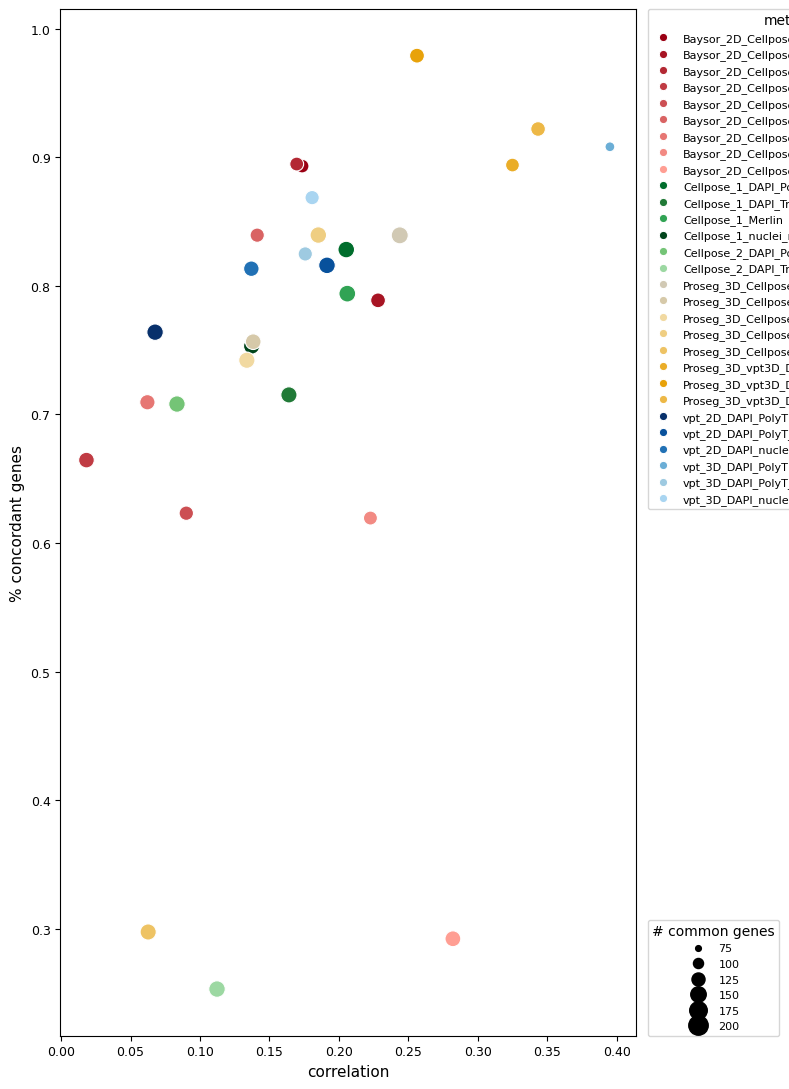

In [21]:
res = {}
concordant_genes = {}
common_genes = {}
cell_type = "ECs"
for method in methods:
    path = Path("/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/aging")/method/"dea"/"aging-by-celltype_MAST_2k_MAST_m18vsm3.xlsx"
    dea = pd.read_excel(path, sheet_name=None)
    r, common, corr_df = plot_corr(dea, jin_dea_sub, cell_type, cell_type_map, plot=False)
    res[method] = r
    common_genes[method] = common
    concordant_genes[method] = sum([np.sign(x[1]['aging_eff_size']) == np.sign(x[1]['jin_eff_size']) for x in corr_df.iterrows()])
res_df = pd.DataFrame(res, index=["correlation", "pval"]).T
res_df['method'] = res_df.index
common_df = pd.DataFrame(common_genes, index=["# common genes"]).T
concord_df = pd.DataFrame(concordant_genes, index=["# concordant genes"]).T
res_df = (res_df
          .merge(common_df, left_index=True, right_index=True)
          .merge(concord_df, left_index=True, right_index=True))
res_df['% concordant genes'] = res_df["# concordant genes"]/res_df["# common genes"]
res_df.to_excel(out_path / f"DEA_corr_{cell_type}.xlsx")
plt.figure(figsize=(8, 11))

min_size, max_size = 50, 150
ax = sns.scatterplot(res_df, y="% concordant genes", x="correlation", hue="method", palette=method_colors, size="# common genes", sizes=(min_size, max_size))
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
handles_all, labels_all = ax.get_legend_handles_labels()
hue_handles = []
hue_labels = []

for h, lab in zip(handles_all, labels_all):
    if lab in res_df["method"].unique():
        hue_handles.append(h)
        hue_labels.append(lab)
ax.legend_.remove()  # remove seaborn's combined legend, if present
hue_legend = ax.legend(
    hue_handles,
    hue_labels,
    title="method",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.,
)

size_data = res_df["# common genes"]
vmin, vmax = size_data.min(), size_data.max()

def value_to_size(v):
    # normalize to [0, 1]
    frac = (v - vmin) / (vmax - vmin) if vmax > vmin else 0.0
    return min_size + frac * (max_size - min_size)

# Desired breaks in *data* units
size_breaks = [75, 100, 125, 150, 175, 200]

scatter = ax.collections[0]
size_handles = [
    mlines.Line2D(
        [], [],
        linestyle="",
        marker="o",
        markersize=(value_to_size(v) ** 0.5),  # legend uses marker *radius*, not area
        color="k",
    )
    for v in size_breaks
]

size_labels = [str(v) for v in size_breaks]
size_legend = ax.legend(
    size_handles,
    size_labels,
    title="# common genes",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    borderaxespad=0.,
)
ax.add_artist(hue_legend)
plt.tight_layout()
plt.savefig(out_path / f"DEA_corr_{cell_type}.png")
plt.savefig(out_path / f"DEA_corr_{cell_type}.pdf")
plt.savefig(out_path / f"DEA_corr_{cell_type}.svg")

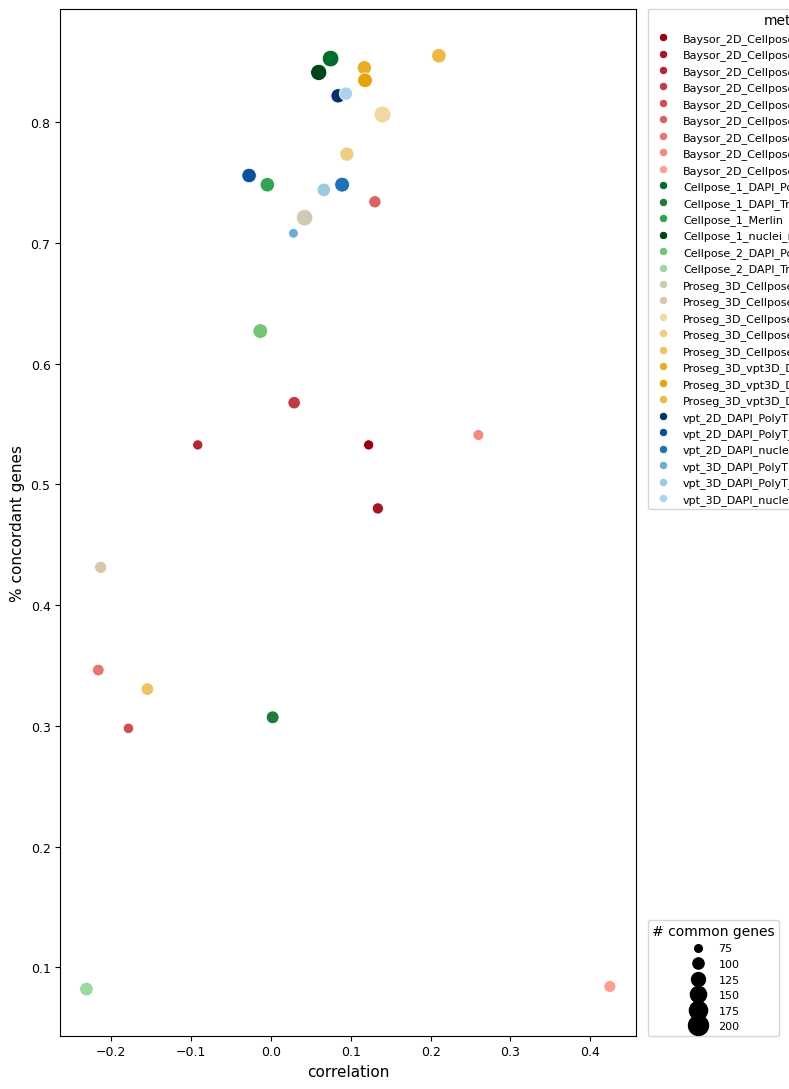

In [22]:
res = {}
concordant_genes = {}
common_genes = {}
cell_type = "Microglia"
for method in methods:
    path = Path("/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/aging")/method/"dea"/"aging-by-celltype_MAST_2k_MAST_m18vsm3.xlsx"
    dea = pd.read_excel(path, sheet_name=None)
    r, common, corr_df = plot_corr(dea, jin_dea_sub, cell_type, cell_type_map, plot=False)
    res[method] = r
    common_genes[method] = common
    concordant_genes[method] = sum([np.sign(x[1]['aging_eff_size']) == np.sign(x[1]['jin_eff_size']) for x in corr_df.iterrows()])
res_df = pd.DataFrame(res, index=["correlation", "pval"]).T
res_df['method'] = res_df.index
common_df = pd.DataFrame(common_genes, index=["# common genes"]).T
concord_df = pd.DataFrame(concordant_genes, index=["# concordant genes"]).T
res_df = (res_df
          .merge(common_df, left_index=True, right_index=True)
          .merge(concord_df, left_index=True, right_index=True))
res_df['% concordant genes'] = res_df["# concordant genes"]/res_df["# common genes"]
res_df.to_excel(out_path / f"DEA_corr_{cell_type}.xlsx")
plt.figure(figsize=(8, 11))

min_size, max_size = 50, 150
ax = sns.scatterplot(res_df, y="% concordant genes", x="correlation", hue="method", palette=method_colors, size="# common genes", sizes=(min_size, max_size))
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
handles_all, labels_all = ax.get_legend_handles_labels()
hue_handles = []
hue_labels = []

for h, lab in zip(handles_all, labels_all):
    if lab in res_df["method"].unique():
        hue_handles.append(h)
        hue_labels.append(lab)
ax.legend_.remove()  # remove seaborn's combined legend, if present
hue_legend = ax.legend(
    hue_handles,
    hue_labels,
    title="method",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.,
)

size_data = res_df["# common genes"]
vmin, vmax = size_data.min(), size_data.max()

def value_to_size(v):
    # normalize to [0, 1]
    frac = (v - vmin) / (vmax - vmin) if vmax > vmin else 0.0
    return min_size + frac * (max_size - min_size)

# Desired breaks in *data* units
size_breaks = [75, 100, 125, 150, 175, 200]

scatter = ax.collections[0]
size_handles = [
    mlines.Line2D(
        [], [],
        linestyle="",
        marker="o",
        markersize=(value_to_size(v) ** 0.5),  # legend uses marker *radius*, not area
        color="k",
    )
    for v in size_breaks
]

size_labels = [str(v) for v in size_breaks]
size_legend = ax.legend(
    size_handles,
    size_labels,
    title="# common genes",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    borderaxespad=0.,
)
ax.add_artist(hue_legend)
plt.tight_layout()
plt.savefig(out_path / f"DEA_corr_{cell_type}.png")
plt.savefig(out_path / f"DEA_corr_{cell_type}.pdf")
plt.savefig(out_path / f"DEA_corr_{cell_type}.svg")

/tmp/ipykernel_905234/1739839932.py:61: RuntimeWarning: invalid value encountered in scalar power
  markersize=(value_to_size(v) ** 0.5),  # legend uses marker *radius*, not area


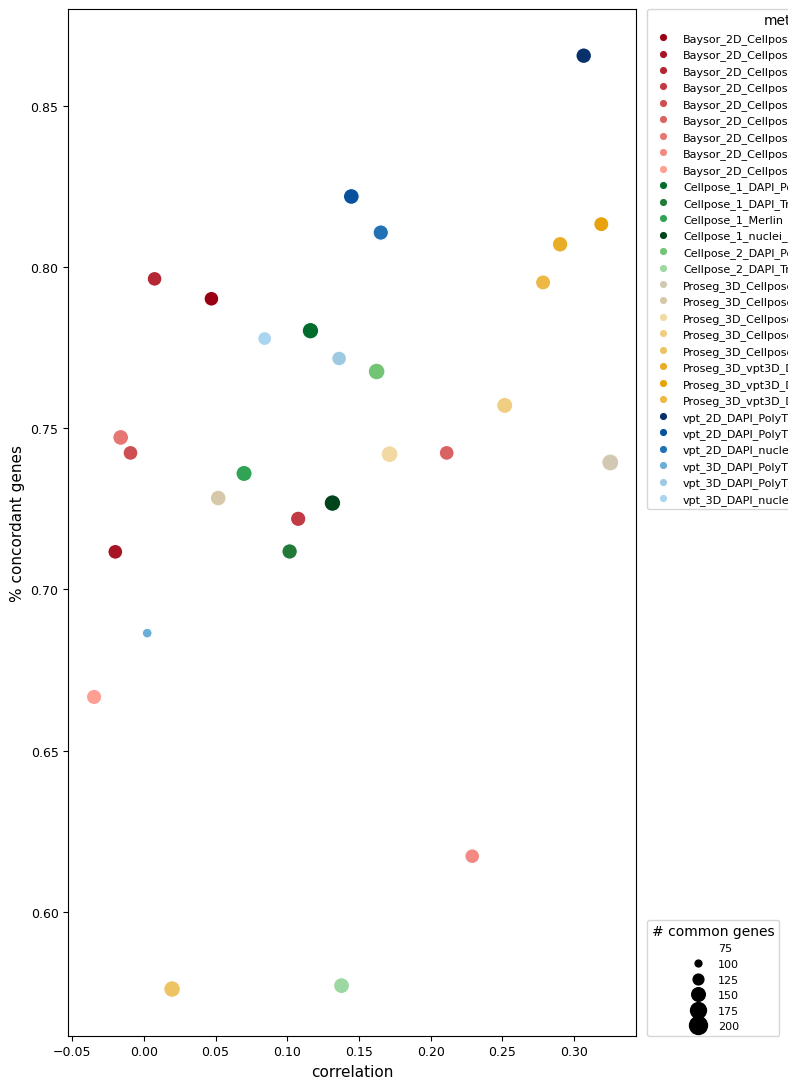

In [23]:
res = {}
concordant_genes = {}
common_genes = {}
cell_type = "SMCs"
for method in methods:
    path = Path("/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/aging")/method/"dea"/"aging-by-celltype_MAST_2k_MAST_m18vsm3.xlsx"
    dea = pd.read_excel(path, sheet_name=None)
    r, common, corr_df = plot_corr(dea, jin_dea_sub, cell_type, cell_type_map, plot=False)
    res[method] = r
    common_genes[method] = common
    concordant_genes[method] = sum([np.sign(x[1]['aging_eff_size']) == np.sign(x[1]['jin_eff_size']) for x in corr_df.iterrows()])
res_df = pd.DataFrame(res, index=["correlation", "pval"]).T
res_df['method'] = res_df.index
common_df = pd.DataFrame(common_genes, index=["# common genes"]).T
concord_df = pd.DataFrame(concordant_genes, index=["# concordant genes"]).T
res_df = (res_df
          .merge(common_df, left_index=True, right_index=True)
          .merge(concord_df, left_index=True, right_index=True))
res_df['% concordant genes'] = res_df["# concordant genes"]/res_df["# common genes"]
res_df.to_excel(out_path / f"DEA_corr_{cell_type}.xlsx")
plt.figure(figsize=(8, 11))

min_size, max_size = 50, 150
ax = sns.scatterplot(res_df, y="% concordant genes", x="correlation", hue="method", palette=method_colors, size="# common genes", sizes=(min_size, max_size))
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
handles_all, labels_all = ax.get_legend_handles_labels()
hue_handles = []
hue_labels = []

for h, lab in zip(handles_all, labels_all):
    if lab in res_df["method"].unique():
        hue_handles.append(h)
        hue_labels.append(lab)
ax.legend_.remove()  # remove seaborn's combined legend, if present
hue_legend = ax.legend(
    hue_handles,
    hue_labels,
    title="method",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.,
)

size_data = res_df["# common genes"]
vmin, vmax = size_data.min(), size_data.max()

def value_to_size(v):
    # normalize to [0, 1]
    frac = (v - vmin) / (vmax - vmin) if vmax > vmin else 0.0
    return min_size + frac * (max_size - min_size)

# Desired breaks in *data* units
size_breaks = [75, 100, 125, 150, 175, 200]

scatter = ax.collections[0]
size_handles = [
    mlines.Line2D(
        [], [],
        linestyle="",
        marker="o",
        markersize=(value_to_size(v) ** 0.5),  # legend uses marker *radius*, not area
        color="k",
    )
    for v in size_breaks
]

size_labels = [str(v) for v in size_breaks]
size_legend = ax.legend(
    size_handles,
    size_labels,
    title="# common genes",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    borderaxespad=0.,
)
ax.add_artist(hue_legend)
plt.tight_layout()
plt.savefig(out_path / f"DEA_corr_{cell_type}.png")
plt.savefig(out_path / f"DEA_corr_{cell_type}.pdf")
plt.savefig(out_path / f"DEA_corr_{cell_type}.svg")

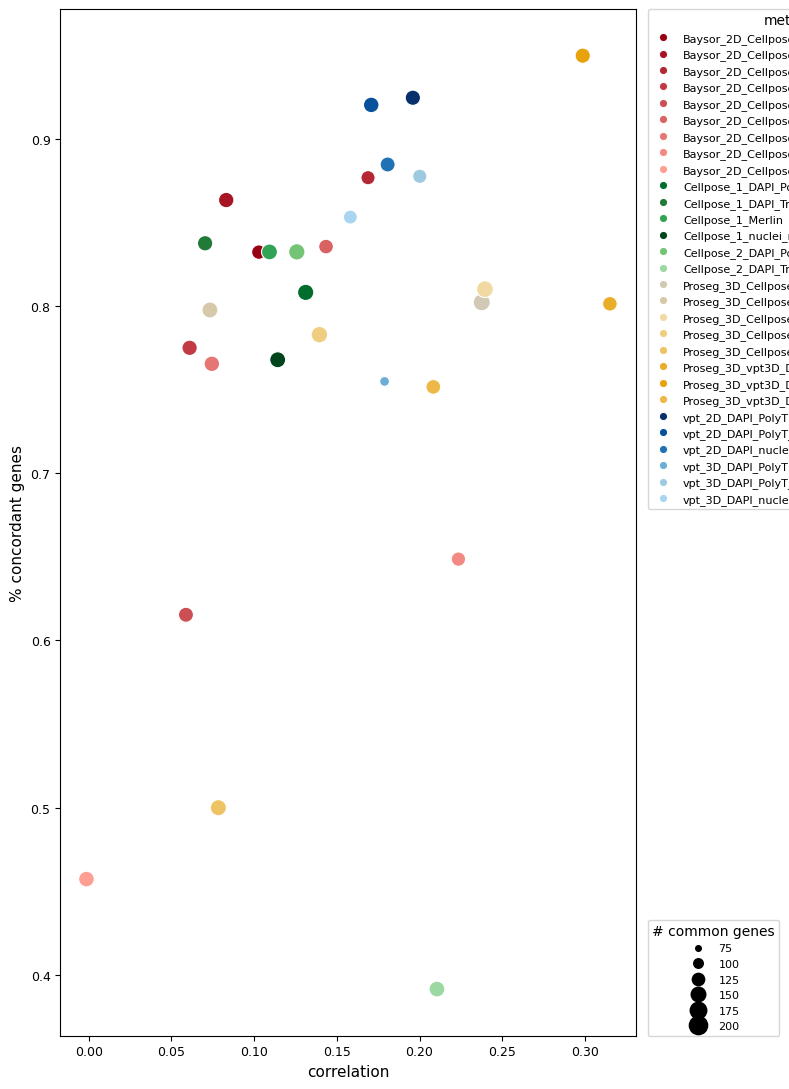

In [24]:
res = {}
concordant_genes = {}
common_genes = {}
cell_type = "Pericytes"
for method in methods:
    path = Path("/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/aging")/method/"dea"/"aging-by-celltype_MAST_2k_MAST_m18vsm3.xlsx"
    dea = pd.read_excel(path, sheet_name=None)
    r, common, corr_df = plot_corr(dea, jin_dea_sub, cell_type, cell_type_map, plot=False)
    res[method] = r
    common_genes[method] = common
    concordant_genes[method] = sum([np.sign(x[1]['aging_eff_size']) == np.sign(x[1]['jin_eff_size']) for x in corr_df.iterrows()])
res_df = pd.DataFrame(res, index=["correlation", "pval"]).T
res_df['method'] = res_df.index
common_df = pd.DataFrame(common_genes, index=["# common genes"]).T
concord_df = pd.DataFrame(concordant_genes, index=["# concordant genes"]).T
res_df = (res_df
          .merge(common_df, left_index=True, right_index=True)
          .merge(concord_df, left_index=True, right_index=True))
res_df['% concordant genes'] = res_df["# concordant genes"]/res_df["# common genes"]
res_df.to_excel(out_path / f"DEA_corr_{cell_type}.xlsx")
plt.figure(figsize=(8, 11))

min_size, max_size = 50, 150
ax = sns.scatterplot(res_df, y="% concordant genes", x="correlation", hue="method", palette=method_colors, size="# common genes", sizes=(min_size, max_size))
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
handles_all, labels_all = ax.get_legend_handles_labels()
hue_handles = []
hue_labels = []

for h, lab in zip(handles_all, labels_all):
    if lab in res_df["method"].unique():
        hue_handles.append(h)
        hue_labels.append(lab)
ax.legend_.remove()  # remove seaborn's combined legend, if present
hue_legend = ax.legend(
    hue_handles,
    hue_labels,
    title="method",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.,
)

size_data = res_df["# common genes"]
vmin, vmax = size_data.min(), size_data.max()

def value_to_size(v):
    # normalize to [0, 1]
    frac = (v - vmin) / (vmax - vmin) if vmax > vmin else 0.0
    return min_size + frac * (max_size - min_size)

# Desired breaks in *data* units
size_breaks = [75, 100, 125, 150, 175, 200]

scatter = ax.collections[0]
size_handles = [
    mlines.Line2D(
        [], [],
        linestyle="",
        marker="o",
        markersize=(value_to_size(v) ** 0.5),  # legend uses marker *radius*, not area
        color="k",
    )
    for v in size_breaks
]

size_labels = [str(v) for v in size_breaks]
size_legend = ax.legend(
    size_handles,
    size_labels,
    title="# common genes",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    borderaxespad=0.,
)
ax.add_artist(hue_legend)
plt.tight_layout()
plt.savefig(out_path / f"DEA_corr_{cell_type}.png")
plt.savefig(out_path / f"DEA_corr_{cell_type}.pdf")
plt.savefig(out_path / f"DEA_corr_{cell_type}.svg")

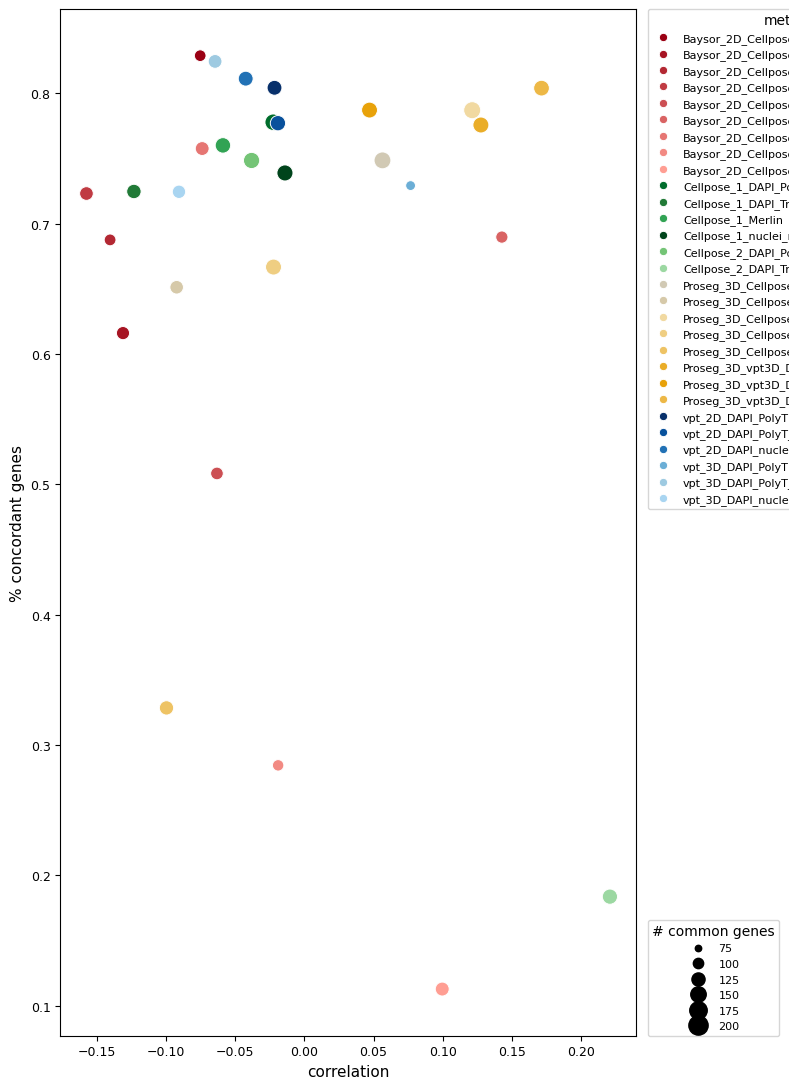

In [25]:
res = {}
concordant_genes = {}
common_genes = {}
cell_type = "OPCs"
for method in methods:
    path = Path("/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/aging")/method/"dea"/"aging-by-celltype_MAST_2k_MAST_m18vsm3.xlsx"
    dea = pd.read_excel(path, sheet_name=None)
    r, common, corr_df = plot_corr(dea, jin_dea_sub, cell_type, cell_type_map, plot=False)
    res[method] = r
    common_genes[method] = common
    concordant_genes[method] = sum([np.sign(x[1]['aging_eff_size']) == np.sign(x[1]['jin_eff_size']) for x in corr_df.iterrows()])
res_df = pd.DataFrame(res, index=["correlation", "pval"]).T
res_df['method'] = res_df.index
common_df = pd.DataFrame(common_genes, index=["# common genes"]).T
concord_df = pd.DataFrame(concordant_genes, index=["# concordant genes"]).T
res_df = (res_df
          .merge(common_df, left_index=True, right_index=True)
          .merge(concord_df, left_index=True, right_index=True))
res_df['% concordant genes'] = res_df["# concordant genes"]/res_df["# common genes"]
res_df.to_excel(out_path / f"DEA_corr_{cell_type}.xlsx")
plt.figure(figsize=(8, 11))

min_size, max_size = 50, 150
ax = sns.scatterplot(res_df, y="% concordant genes", x="correlation", hue="method", palette=method_colors, size="# common genes", sizes=(min_size, max_size))
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
handles_all, labels_all = ax.get_legend_handles_labels()
hue_handles = []
hue_labels = []

for h, lab in zip(handles_all, labels_all):
    if lab in res_df["method"].unique():
        hue_handles.append(h)
        hue_labels.append(lab)
ax.legend_.remove()  # remove seaborn's combined legend, if present
hue_legend = ax.legend(
    hue_handles,
    hue_labels,
    title="method",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.,
)

size_data = res_df["# common genes"]
vmin, vmax = size_data.min(), size_data.max()

def value_to_size(v):
    # normalize to [0, 1]
    frac = (v - vmin) / (vmax - vmin) if vmax > vmin else 0.0
    return min_size + frac * (max_size - min_size)

# Desired breaks in *data* units
size_breaks = [75, 100, 125, 150, 175, 200]

scatter = ax.collections[0]
size_handles = [
    mlines.Line2D(
        [], [],
        linestyle="",
        marker="o",
        markersize=(value_to_size(v) ** 0.5),  # legend uses marker *radius*, not area
        color="k",
    )
    for v in size_breaks
]

size_labels = [str(v) for v in size_breaks]
size_legend = ax.legend(
    size_handles,
    size_labels,
    title="# common genes",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    borderaxespad=0.,
)
ax.add_artist(hue_legend)
plt.tight_layout()
plt.savefig(out_path / f"DEA_corr_{cell_type}.png")
plt.savefig(out_path / f"DEA_corr_{cell_type}.pdf")
plt.savefig(out_path / f"DEA_corr_{cell_type}.svg")

In [91]:
res_df

,correlation,pval,method,# common genes,# concordant genes,% concordant genes
Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,-0.075189,0.343155,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,111,92,0.828829
Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,-0.130949,0.124403,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,125,77,0.616000
Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2,-0.140277,0.085809,Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2,112,77,0.687500
Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8,-0.157346,0.031966,Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8,130,94,0.723077
Baysor_2D_Cellpose_1_nuclei_model_1.0,-0.063091,0.508701,Baysor_2D_Cellpose_1_nuclei_model_1.0,120,61,0.508333
Baysor_2D_Cellpose_2_DAPI_PolyT_0.2,0.142694,0.085768,Baysor_2D_Cellpose_2_DAPI_PolyT_0.2,116,80,0.689655
Baysor_2D_Cellpose_2_DAPI_PolyT_0.8,-0.073752,0.343530,Baysor_2D_Cellpose_2_DAPI_PolyT_0.8,132,100,0.757576
Baysor_2D_Cellpose_2_DAPI_Transcripts_0.2,-0.018897,0.890057,Baysor_2D_Cellpose_2_DAPI_Transcripts_0.2,109,31,0.284404
Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8,0.099626,0.659134,Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8,133,15,0.112782
Cellpose_1_DAPI_PolyT,-0.022471,0.740889,Cellpose_1_DAPI_PolyT,162,126,0.777778


In [14]:
order_opc_df = (
    order_opc
    .reset_index(drop=True)              # 0..n-1
    .to_frame(name='method')             # col name
)
order_opc_df['rank_opc'] = (
    order_opc_df.index + 1               # 1-based rank
)
order_opc_df = order_opc_df.set_index("method")
order_ecs_df = (
    order_ec
    .reset_index(drop=True)              # 0..n-1
    .to_frame(name='method')             # col name
)
order_ecs_df['rank_ecs'] = (
    order_ecs_df.index + 1               # 1-based rank
)
order_ecs_df = order_ecs_df.set_index("method")
order_peri_df = (
    order_peri
    .reset_index(drop=True)              # 0..n-1
    .to_frame(name='method')             # col name
)
order_peri_df['rank_peri'] = (
    order_peri_df.index + 1               # 1-based rank
)
order_peri_df = order_peri_df.set_index("method")
order_smcs_df = (
    order_smc
    .reset_index(drop=True)              # 0..n-1
    .to_frame(name='method')             # col name
)
order_smcs_df['rank_smcs'] = (
    order_smcs_df.index + 1               # 1-based rank
)
order_smcs_df = order_smcs_df.set_index("method")
order_micro_df = (
    order_micro
    .reset_index(drop=True)              # 0..n-1
    .to_frame(name='method')             # col name
)
order_micro_df['rank_micro'] = (
    order_micro_df.index + 1               # 1-based rank
)
order_micro_df = order_micro_df.set_index("method")
merged_ranks = (order_ecs_df
                 .merge(order_smcs_df, left_index=True, right_index=True)
                 .merge(order_peri_df, left_index=True, right_index=True)
                 .merge(order_opc_df, left_index=True, right_index=True)
                 .merge(order_micro_df, left_index=True, right_index=True)
               )

merged_ranks["sum_vasc"] = merged_ranks[["rank_ecs", "rank_smcs", "rank_peri"]].sum(axis=1)
merged_ranks["sum_total"] = merged_ranks.sum(axis=1)

order_vasc = merged_ranks.sort_values('sum_vasc', ascending=True).index.to_series()
order_vasc_df = (
    order_vasc
    .reset_index(drop=True)              # 0..n-1
    .to_frame(name='method')             # col name
)
order_vasc_df['rank_vasc'] = (
    order_vasc_df.index + 1               # 1-based rank
)
order_vasc_df = order_vasc_df.set_index("method")

order_total = merged_ranks.sort_values('sum_total', ascending=True).index.to_series()
order_total_df = (
    order_total
    .reset_index(drop=True)              # 0..n-1
    .to_frame(name='method')             # col name
)
order_total_df['rank_total'] = (
    order_total_df.index + 1               # 1-based rank
)
order_total_df = order_total_df.set_index("method")

merged_ranks = (merged_ranks
                 .merge(order_vasc_df, left_index=True, right_index=True)
                 .merge(order_total_df, left_index=True, right_index=True)
               )
merged_ranks.drop(["sum_vasc", "sum_total"], axis=1, inplace=True)
merged_ranks.sort_values("rank_vasc")

,rank_ecs,rank_smcs,rank_peri,rank_opc,rank_micro,rank_vasc,rank_total
method,,,,,,,
Proseg_3D_vpt3D_DAPI_PolyT_nuclei,3,16,2,26,5,1,3
Proseg_3D_vpt3D_DAPI_PolyT,9,12,1,20,13,2,5
Proseg_3D_vpt3D_DAPI_nuclei,2,2,19,30,7,3,9
Proseg_3D_Cellpose_2_DAPI_PolyT,7,6,11,4,12,4,1
Proseg_3D_Cellpose_1_DAPI_PolyT,10,5,10,18,14,5,7
vpt_3D_DAPI_PolyT_nuclei,5,14,8,3,15,6,2
vpt_3D_DAPI_nuclei,4,1,23,10,11,7,4
Proseg_3D_Cellpose_1_nuclei_model,12,13,3,22,3,8,6
vpt_2D_DAPI_PolyT,23,3,5,13,17,9,11


(SignificanceResult(statistic=np.float64(0.16164596273291926), pvalue=np.float64(0.0023386051116517474)),
 161)

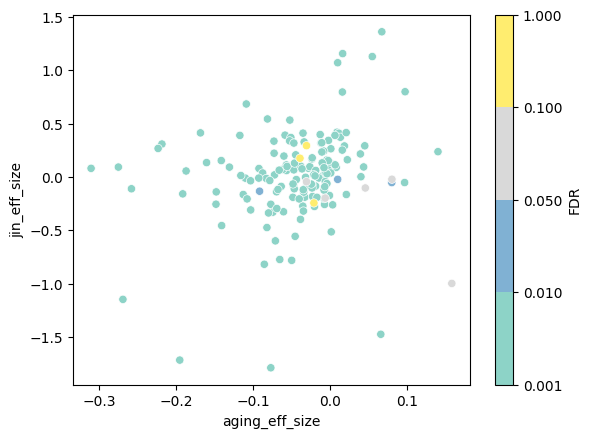

In [100]:
plot_corr(dea, jin_dea_sub, "Pericytes", cell_type_map)

(SignificanceResult(statistic=np.float64(0.14220846233230136), pvalue=np.float64(0.005759880382513869)),
 176)

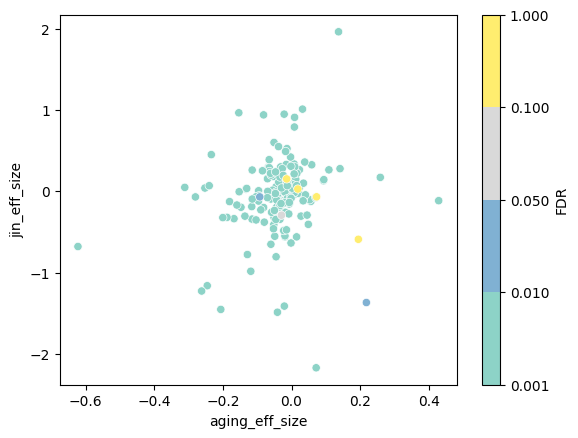

In [101]:
plot_corr(dea, jin_dea_sub, "SMCs", cell_type_map)

# Comparison between segmentation algorithms

In [80]:
def plot_corr_between_algos(dea_1, dea_2, cell_type, plot=True):
    dea_sub_1 = dea_1[cell_type]
    dea_sub_1 = dea_sub_1[dea_sub_1['FDR']<0.05]
    
    dea_sub_2 = dea_2[cell_type]
    dea_sub_2 = dea_sub_2[dea_sub_2['FDR']<0.05]
    
    common_genes = list(set(dea_sub_1['gene']) & set(dea_sub_2['gene']))
    dea_sub_1 = dea_sub_1[dea_sub_1['gene'].isin(common_genes)]
    dea_sub_2 = dea_sub_2[dea_sub_2['gene'].isin(common_genes)]
    dea_sub_2 = dea_sub_2.set_index("gene")
    dea_sub_2 = dea_sub_2.loc[dea_sub_1["gene"]]
    dea_sub_1 = dea_sub_1.set_index("gene")
    corr_df = pd.DataFrame({"dea_eff_size_1": dea_sub_1['log2FC'], "dea_eff_size_2": dea_sub_2['log2FC'], "aging_padj": dea_sub_1['FDR']}, index=dea_sub_2.index)
    if plot:
        ax = sns.scatterplot(corr_df, x="dea_eff_size_1", y="dea_eff_size_2", hue="aging_padj", palette=cmap, hue_norm=norm, legend=False)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = ax.figure.colorbar(sm, ax=ax, boundaries=breaks, ticks=breaks)
        cbar.set_label("FDR")
    return pearsonr(corr_df["dea_eff_size_1"], corr_df["dea_eff_size_2"]), len(common_genes)

In [81]:
res = {}
res["ECs"] = pd.DataFrame(columns = methods, index = methods, dtype=float)
res["SMCs"] = pd.DataFrame(columns = methods, index = methods, dtype=float)
res["Pericytes"] = pd.DataFrame(columns = methods, index = methods, dtype=float)
res["Microglia"] = pd.DataFrame(columns = methods, index = methods, dtype=float)
res["OPCs"] = pd.DataFrame(columns = methods, index = methods, dtype=float)
for method_1 in tqdm(methods):
    path = Path("/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/aging")/method_1/"dea"/"aging-by-celltype_MAST_2k_MAST_m18vsm3.xlsx"
    dea_1 = pd.read_excel(path, sheet_name=None)
    for method_2 in methods:
        path = Path("/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/aging")/method_2/"dea"/"aging-by-celltype_MAST_2k_MAST_m18vsm3.xlsx"
        dea_2 = pd.read_excel(path, sheet_name=None)
        for celltype in ["ECs", "SMCs", "Pericytes", "Microglia", "OPCs"]:
            r, _ = plot_corr_between_algos(dea_1, dea_2, celltype, plot=False)
            res[celltype].loc[method_1, method_2] = r.statistic
res

100%|██████████| 29/29 [03:36<00:00,  7.45s/it]


{'ECs':                                            Baysor_2D_Cellpose_1_DAPI_PolyT_0.2  \
 Baysor_2D_Cellpose_1_DAPI_PolyT_0.2                                   1.000000   
 Baysor_2D_Cellpose_1_DAPI_PolyT_0.8                                   0.887608   
 Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2                             0.896328   
 Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8                             0.881553   
 Baysor_2D_Cellpose_1_nuclei_model_1.0                                 0.910690   
 Baysor_2D_Cellpose_2_DAPI_PolyT_0.2                                  -0.193267   
 Baysor_2D_Cellpose_2_DAPI_PolyT_0.8                                   0.891171   
 Baysor_2D_Cellpose_2_DAPI_Transcripts_0.2                             0.432250   
 Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8                             0.605950   
 Cellpose_1_DAPI_PolyT                                                 0.886397   
 Cellpose_1_DAPI_Transcripts                                           0.864970 

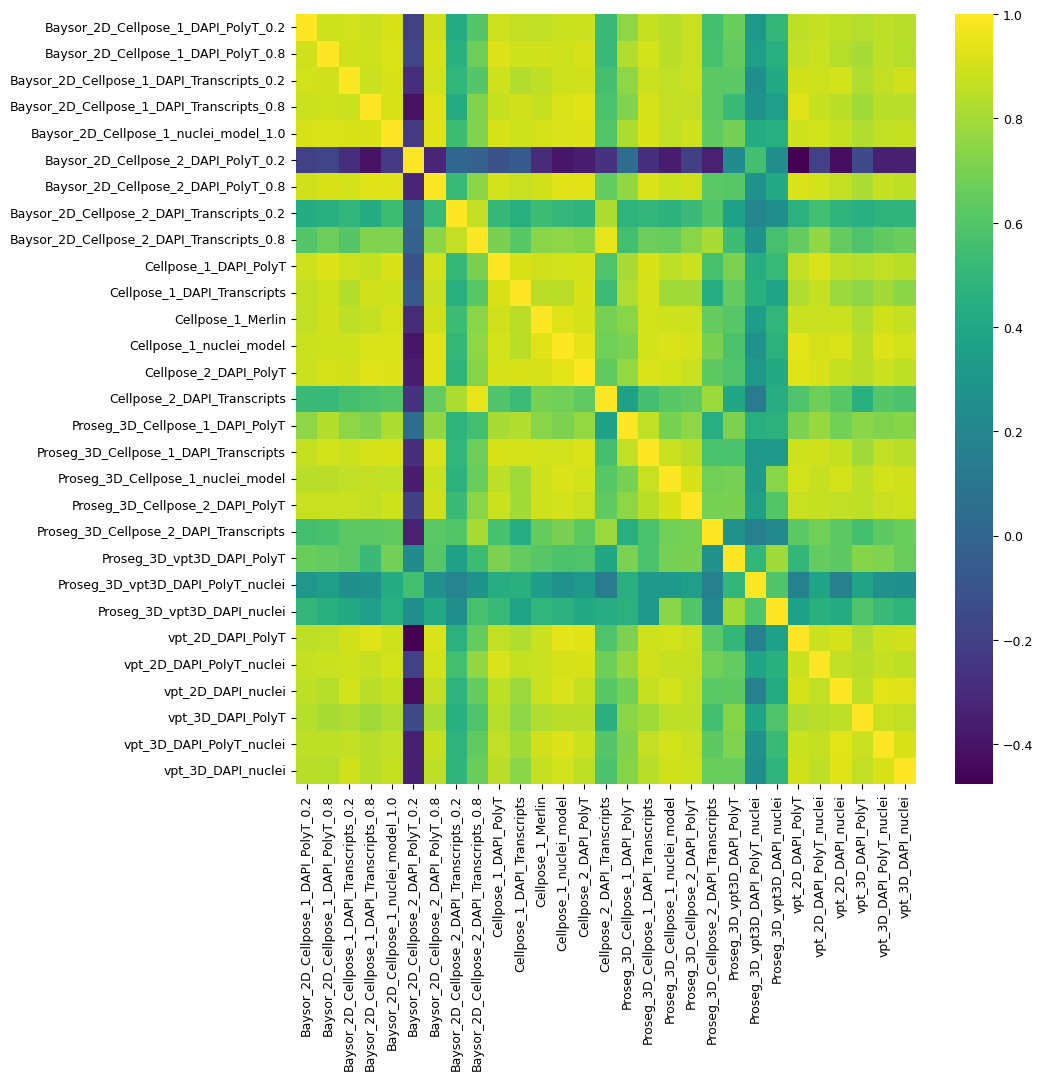

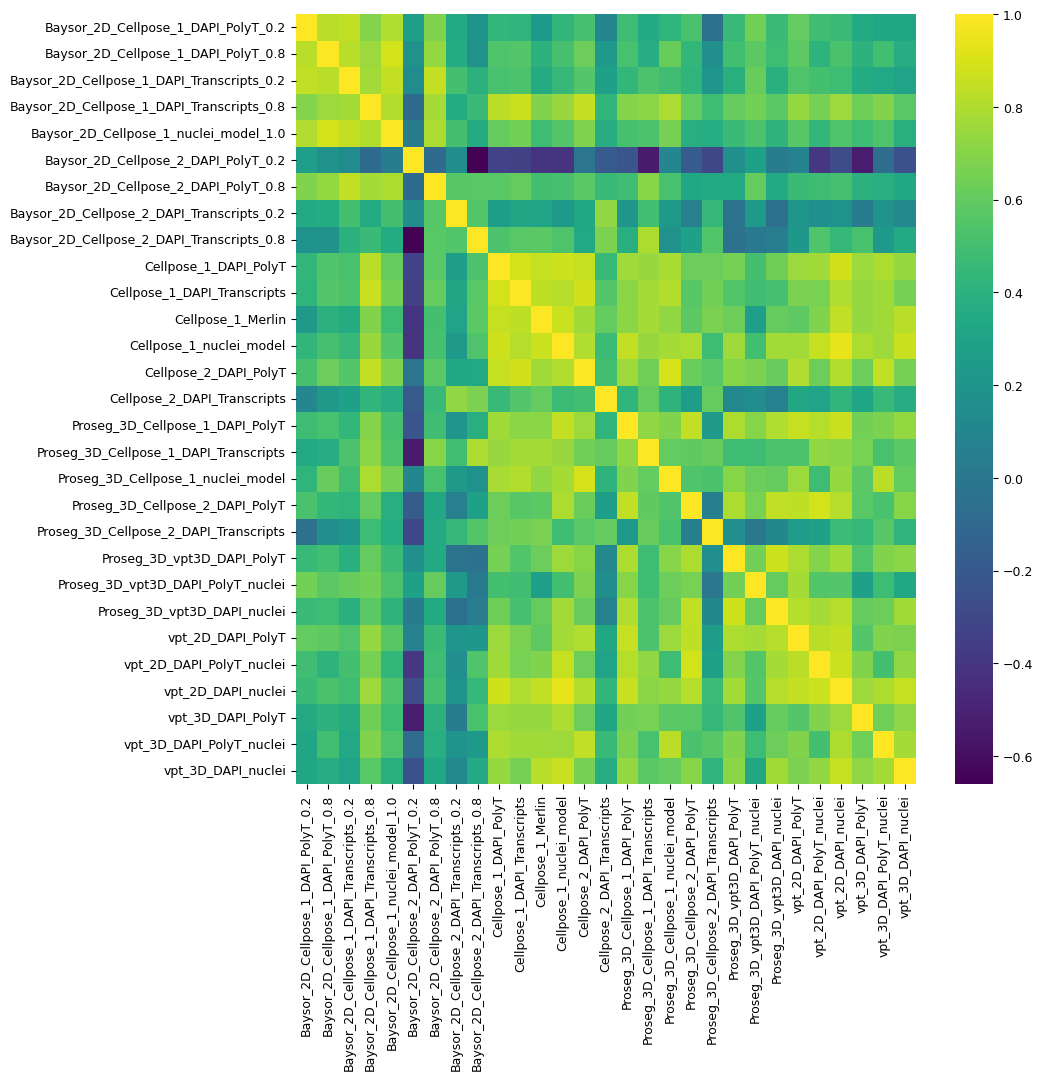

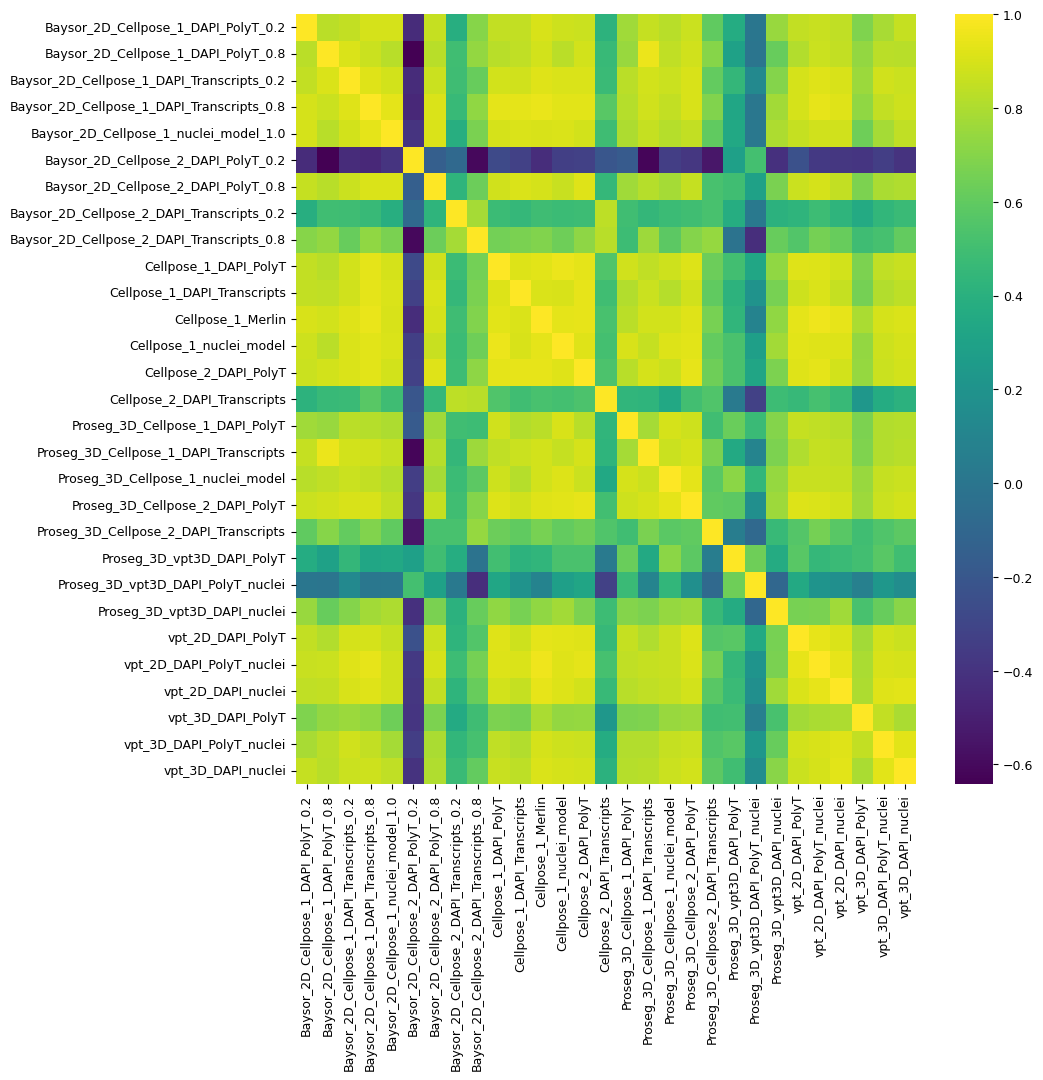

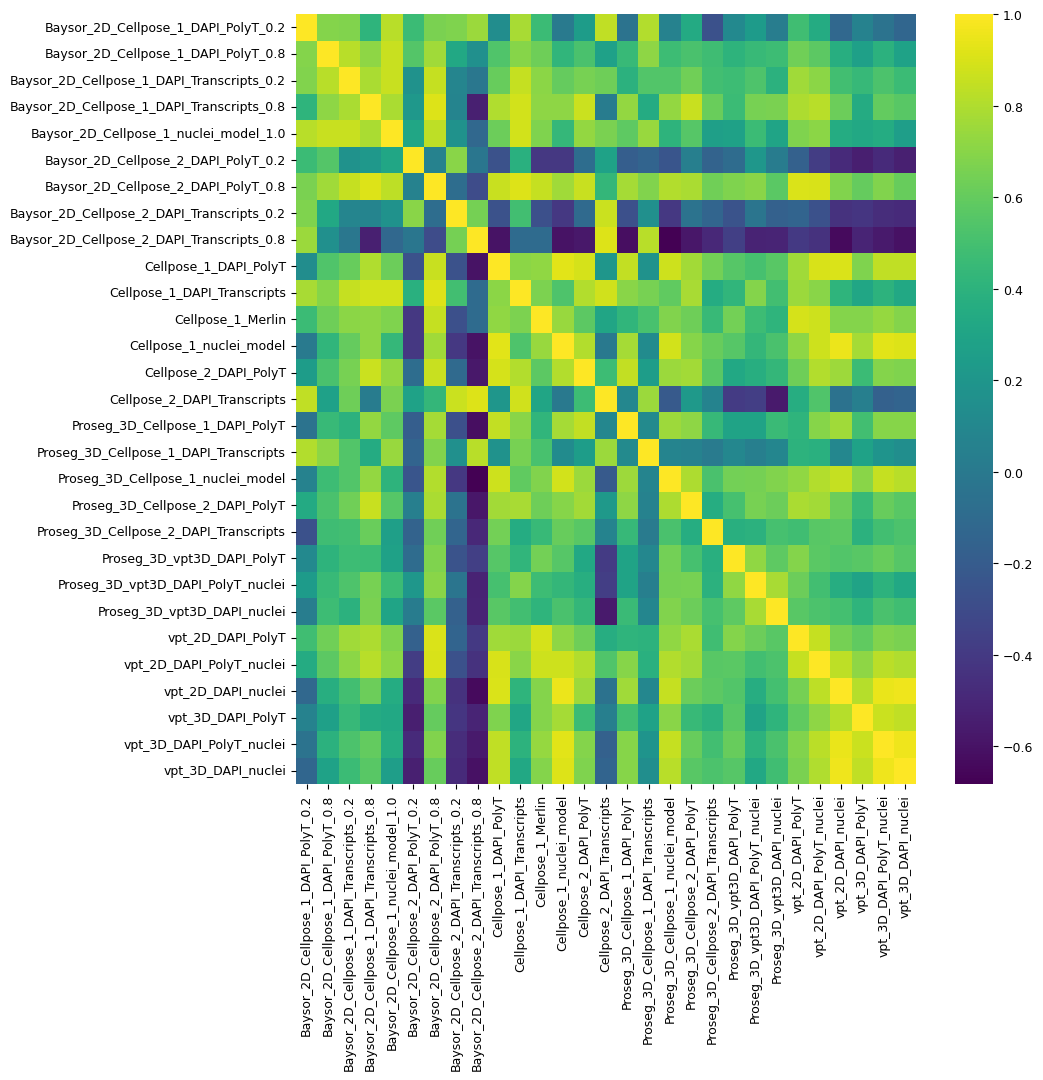

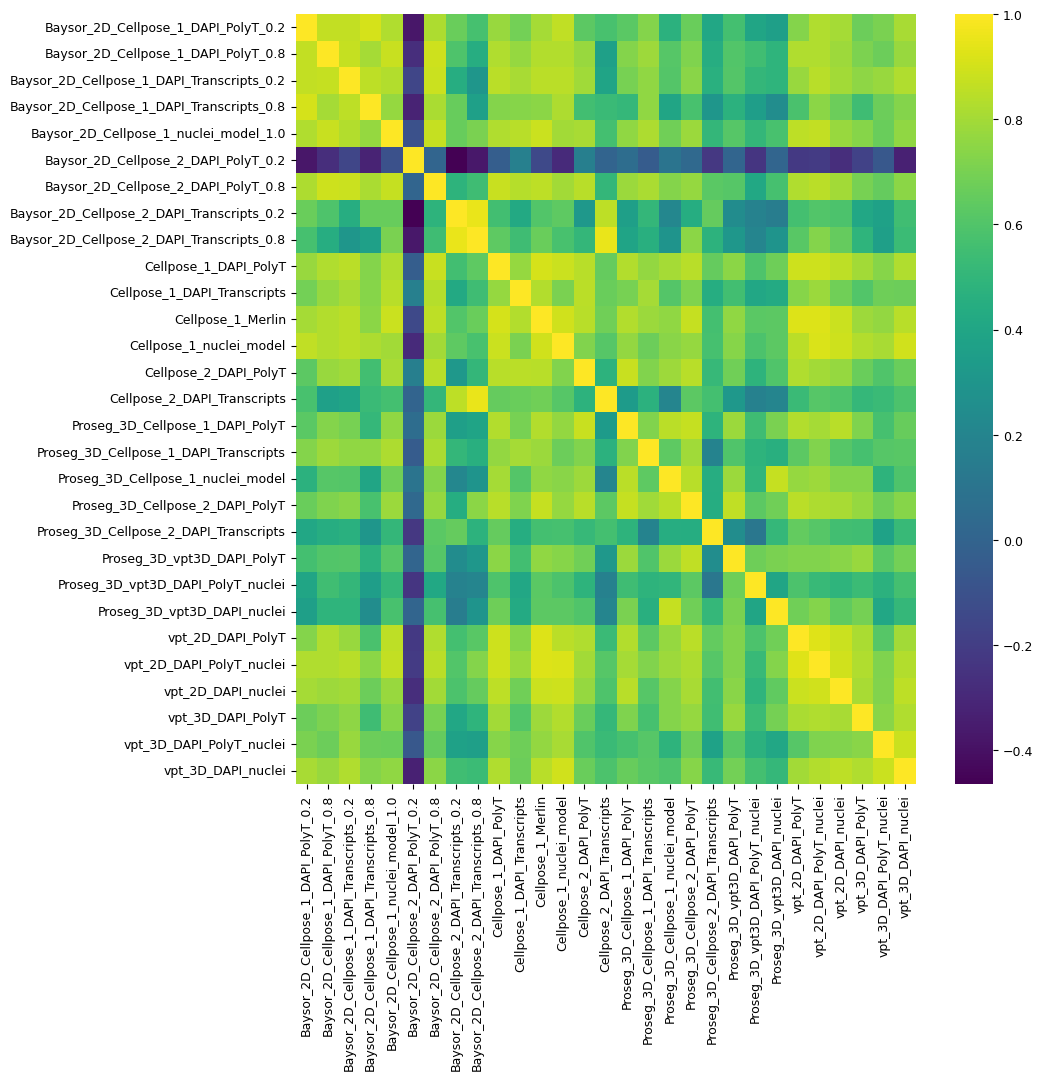

In [82]:
for key, values in res.items():
    values.to_excel(out_path / f"DEA_corr_between_methods_{key}.xlsx")
    plt.figure(figsize=(10, 10))
    sns.heatmap(values, cmap="viridis")
    plt.savefig(out_path / f"DEA_corr_between_methods_{key}.png")
    plt.savefig(out_path / f"DEA_corr_between_methods_{key}.pdf")
    plt.savefig(out_path / f"DEA_corr_between_methods_{key}.svg")